In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [2]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

In [3]:
param_grid = {
    "model__C": np.logspace(-3, 2, 6), # log scale search over 10^-3, 10^2, 6 splits: 0.001, 0.01, 0.1, 1, 10, 100. Smaller C = stronger regulisation
    "model__penalty": ["elasticnet"] # balance between L1 and L2 regulisation
}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, solver = "saga")) # saga required for elasticnet
])

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring="roc_auc",
    refit=True,        # refit best model on full training set
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"Best C:       {grid_search.best_params_['model__C']}")
print(f"Best AUC-ROC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C:       0.01
Best AUC-ROC: 0.8579


C:\Users\frane\anaconda3\envs\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [4]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[[
    "param_model__C",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]].copy()

results.columns = ["C", "mean_auc_roc", "std_auc_roc", "mean_train_auc"]
results["C"] = results["C"].astype(float)
results = results.sort_values("C").reset_index(drop=True)

print(results.to_string(index=False))

      C  mean_auc_roc  std_auc_roc  mean_train_auc
  0.001      0.853415     0.010635        0.855254
  0.010      0.857925     0.011102        0.861311
  0.100      0.857854     0.011308        0.861802
  1.000      0.857838     0.011330        0.861913
 10.000      0.857854     0.011310        0.862014
100.000      0.857826     0.011321        0.862039


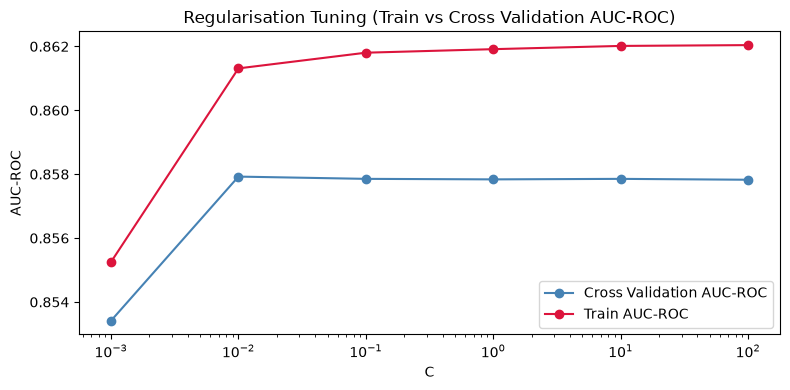

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(results["C"], results["mean_auc_roc"], marker="o", color="steelblue", label="Cross Validation AUC-ROC")
plt.plot(results["C"], results["mean_train_auc"], marker="o", color="crimson", label="Train AUC-ROC")

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("AUC-ROC")
plt.title("Regularisation Tuning (Train vs Cross Validation AUC-ROC)")
plt.legend()
plt.tight_layout()
plt.show()

# We can see at C = 10^-3, where regulisation is strong, that gap is small but the scores are low. The model is underfit, too constrained to learn properly.
# At C=0.1 onwards, scores plateau. I've chose C=0.1

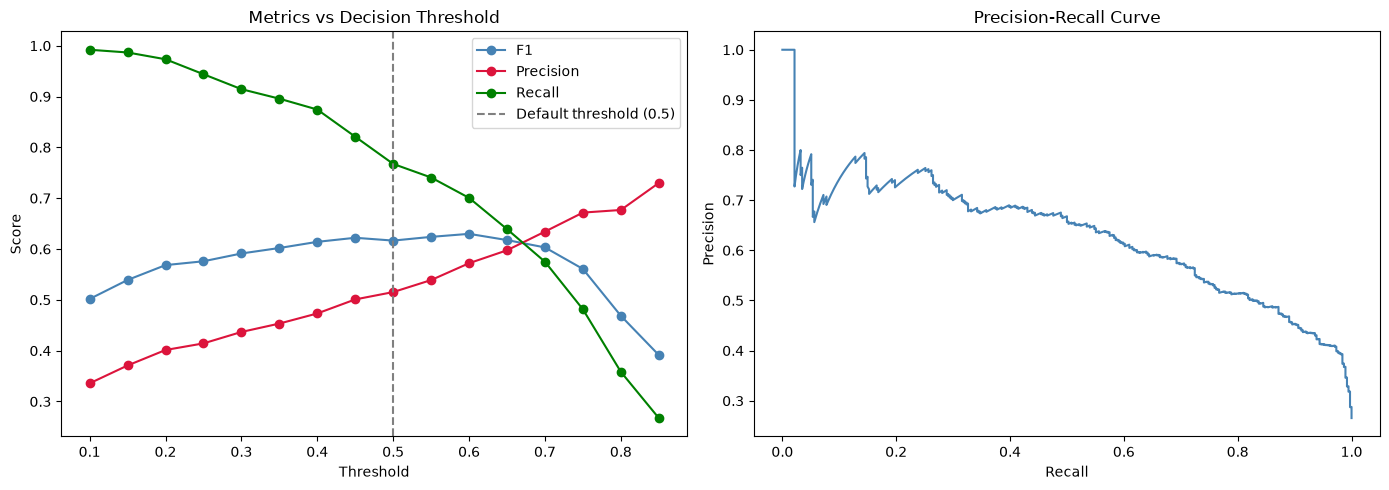

In [6]:
best_model = grid_search.best_estimator_ # best model during hyperparameter tuning
y_probability = best_model.predict_proba(X_test)[:, 1] 

thresholds = np.arange(0.1, 0.9, 0.05) # 0.1 to 0.85, if < threshold, class 0, else 1
f1_scores, precisions, recalls = [], [], []

for threshold in thresholds:
    y_prediction = (y_probability >= threshold).astype(int) # convert bool to int
    f1_scores.append(f1_score(y_test, y_prediction))
    precisions.append(precision_score(y_test, y_prediction))
    recalls.append(recall_score(y_test, y_prediction))

fig, axis = plt.subplots(1, 2, figsize=(14, 5))

axis[0].plot(thresholds, f1_scores, label="F1", marker="o", color="steelblue") # marker for threshold pos
axis[0].plot(thresholds, precisions, label="Precision", marker="o", color="crimson")
axis[0].plot(thresholds, recalls, label="Recall", marker="o", color="green")
axis[0].axvline(x=0.5, linestyle="--", color="grey", label="Default threshold (0.5)") # usual threshold
axis[0].set_xlabel("Threshold")
axis[0].set_ylabel("Score")
axis[0].set_title("Metrics vs Decision Threshold")
axis[0].legend()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_probability) # sorts all probabilities as thresholds
axis[1].plot(recall_curve, precision_curve, color="steelblue")
axis[1].set_xlabel("Recall")
axis[1].set_ylabel("Precision")
axis[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

Default threshold: 0.5
F1:        0.6165
Recall:    0.7674
Precision: 0.5153
AUC-ROC:   0.7533

Tuned threshold set for maximum recall: 0.10
F1:        0.5017
Recall:    0.9920
Precision: 0.3357
AUC-ROC:   0.6414

Tuned threshold set for maximum F1: 0.60
F1:        0.6298
Recall:    0.7005
Precision: 0.5721
AUC-ROC:   0.7556

Tuned threshold set for trade-off: 0.4
F1:        0.6141
Recall:    0.8743
Precision: 0.4732
AUC-ROC:   0.7613

Tuned threshold set for trade-off: 0.45
F1:        0.6221
Recall:    0.8209
Precision: 0.5008
AUC-ROC:   0.7626

Tuned threshold set for trade-off: 0.3
F1:        0.5912
Recall:    0.9144
Precision: 0.4368
AUC-ROC:   0.7442


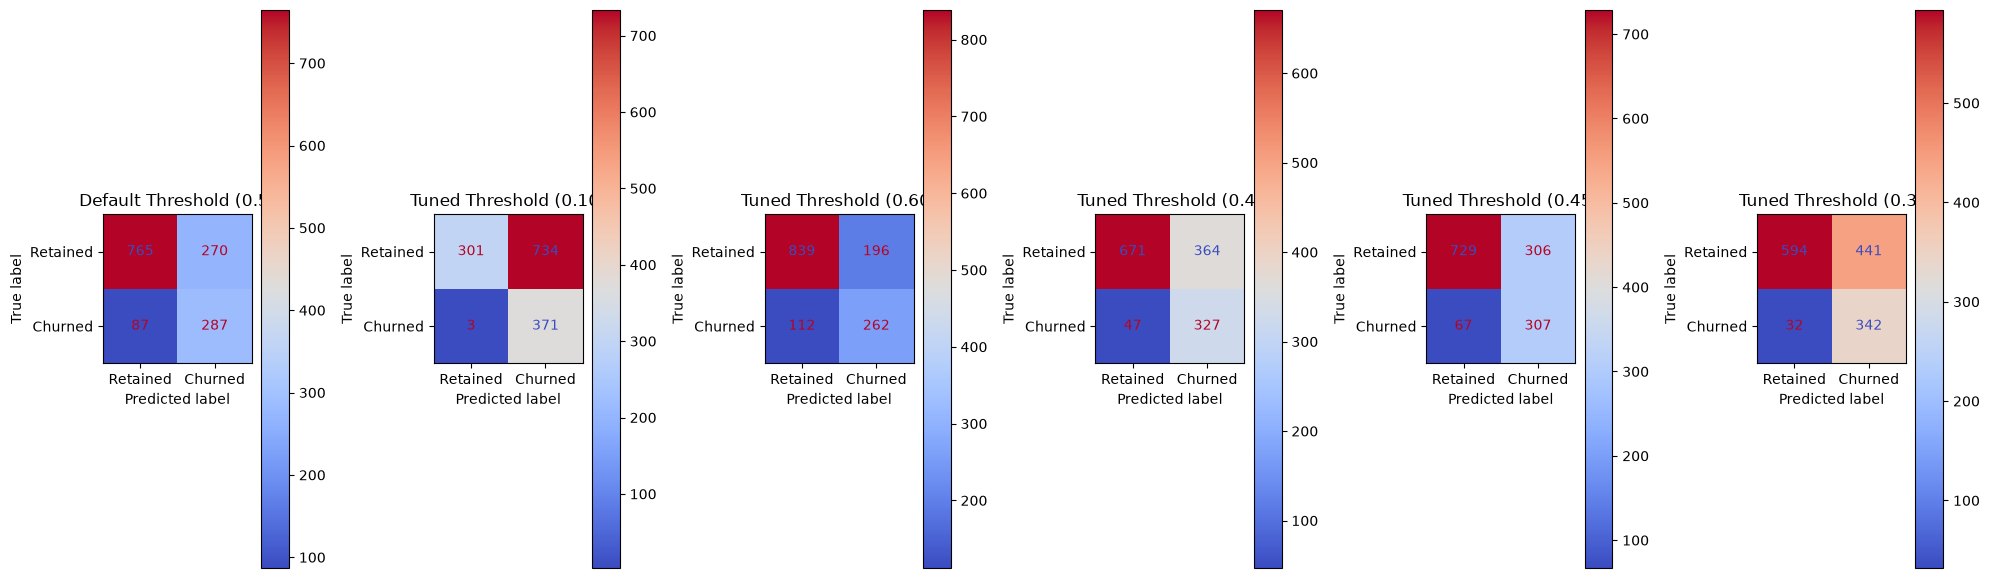


Classification for tuned threshold (recall)
              precision    recall  f1-score   support

    Retained       0.99      0.29      0.45      1035
     Churned       0.34      0.99      0.50       374

    accuracy                           0.48      1409
   macro avg       0.66      0.64      0.48      1409
weighted avg       0.82      0.48      0.46      1409


Classification for tuned threshold (f1)
              precision    recall  f1-score   support

    Retained       0.88      0.81      0.84      1035
     Churned       0.57      0.70      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [14]:
best_threshold_for_recall = thresholds[np.argmax(recalls)] # np.argmax() returns indices of max
# for f1: 0.6, for recall: 0.1
best_threshold_for_f1 = thresholds[np.argmax(f1_scores)]

y_prediction_tuned_recall = (y_probability >= best_threshold_for_recall).astype(int)
y_prediction_without_tuning = (y_probability >= 0.5).astype(int) # 0.5 as default
y_prediction_tuned_f1 = (y_probability >= best_threshold_for_f1).astype(int)
y_prediction_first_trade_off = (y_probability >= 0.4).astype(int)
y_prediction_second_trade_off = (y_probability >= 0.45).astype(int)
y_prediction_third_trade_off = (y_probability >= 0.3).astype(int)

print("Default threshold: 0.5")
print(f"F1:        {f1_score(y_test, y_prediction_without_tuning):.4f}")
print(f"Recall:    {recall_score(y_test, y_prediction_without_tuning):.4f}")
print(f"Precision: {precision_score(y_test, y_prediction_without_tuning):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prediction_without_tuning):.4f}")

print(f"\nTuned threshold set for maximum recall: {best_threshold_for_recall:.2f}")
print(f"F1:        {f1_score(y_test, y_prediction_tuned_recall):.4f}")
print(f"Recall:    {recall_score(y_test, y_prediction_tuned_recall):.4f}")
print(f"Precision: {precision_score(y_test, y_prediction_tuned_recall):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prediction_tuned_recall):.4f}")

print(f"\nTuned threshold set for maximum F1: {best_threshold_for_f1:.2f}")
print(f"F1:        {f1_score(y_test, y_prediction_tuned_f1):.4f}")
print(f"Recall:    {recall_score(y_test, y_prediction_tuned_f1):.4f}")
print(f"Precision: {precision_score(y_test, y_prediction_tuned_f1):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prediction_tuned_f1):.4f}")

print(f"\nTuned threshold set for trade-off: 0.4")
print(f"F1:        {f1_score(y_test, y_prediction_first_trade_off):.4f}")
print(f"Recall:    {recall_score(y_test, y_prediction_first_trade_off):.4f}")
print(f"Precision: {precision_score(y_test, y_prediction_first_trade_off):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prediction_first_trade_off):.4f}")

print(f"\nTuned threshold set for trade-off: 0.45")
print(f"F1:        {f1_score(y_test, y_prediction_second_trade_off):.4f}")
print(f"Recall:    {recall_score(y_test, y_prediction_second_trade_off):.4f}")
print(f"Precision: {precision_score(y_test, y_prediction_second_trade_off):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prediction_second_trade_off):.4f}")

print(f"\nTuned threshold set for trade-off: 0.3")
print(f"F1:        {f1_score(y_test, y_prediction_third_trade_off):.4f}")
print(f"Recall:    {recall_score(y_test, y_prediction_third_trade_off):.4f}")
print(f"Precision: {precision_score(y_test, y_prediction_third_trade_off):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prediction_third_trade_off):.4f}")

fig, axis = plt.subplots(1, 6, figsize=(20, 13))

confusion_matrix_default = confusion_matrix(y_test, y_prediction_without_tuning)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_default, display_labels=["Retained", "Churned"]).plot(cmap="coolwarm", ax=axis[0])
axis[0].set_title("Default Threshold (0.5)")

confusion_matrix_recall = confusion_matrix(y_test, y_prediction_tuned_recall)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_recall, display_labels=["Retained", "Churned"]).plot(cmap="coolwarm", ax=axis[1])
axis[1].set_title(f"Tuned Threshold ({best_threshold_for_recall:.2f})")

confusion_matrix_f1 = confusion_matrix(y_test, y_prediction_tuned_f1)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_f1, display_labels=["Retained", "Churned"]).plot(cmap="coolwarm", ax=axis[2])
axis[2].set_title(f"Tuned Threshold ({best_threshold_for_f1:.2f})")

confusion_matrix_first = confusion_matrix(y_test, y_prediction_first_trade_off)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_first, display_labels=["Retained", "Churned"]).plot(cmap="coolwarm", ax=axis[3])
axis[3].set_title(f"Tuned Threshold (0.4)")

confusion_matrix_second = confusion_matrix(y_test, y_prediction_second_trade_off)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_second, display_labels=["Retained", "Churned"]).plot(cmap="coolwarm", ax=axis[4])
axis[4].set_title(f"Tuned Threshold (0.45)")

confusion_matrix_third = confusion_matrix(y_test, y_prediction_third_trade_off)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_third, display_labels=["Retained", "Churned"]).plot(cmap="coolwarm", ax=axis[5])
axis[5].set_title(f"Tuned Threshold (0.3)")

plt.tight_layout()
plt.show()

print("\nClassification for tuned threshold (recall)")
print(classification_report(y_test, y_prediction_tuned_recall, target_names=["Retained", "Churned"]))

print("\nClassification for tuned threshold (f1)")
print(classification_report(y_test, y_prediction_tuned_f1, target_names=["Retained", "Churned"]))

In [ ]:
# Check if probabilities are well calibrated with real churn rate, and not over confident

real_probability, predicted_probability = calibration_curve(y_test, y_probability, n_bins=10)

calibrated_model = CalibratedClassifierCV(best_model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)
calibrated_y_probability = calibrated_model.predict_proba(X_test)[:,1]

calibrated_real_probability, calibrated_predicted_probability = calibration_curve(y_test, calibrated_y_probability, n_bins=10)

plt.figure(figsize=(7, 5))
plt.plot(predicted_probability, real_probability, marker="o", color="steelblue", label="Before calibration")
plt.plot(calibrated_predicted_probability, calibrated_real_probability, marker="o", color="crimson", label="After calibration")
plt.plot([0, 1], [0, 1], color="grey", label="Perfect calibration") # straight y=x line if perfect fit
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration - Before vs After")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC-ROC before calibration: {roc_auc_score(y_test, y_probability):.4f}")
print(f"AUC-ROC after calibration:  {roc_auc_score(y_test, calibrated_y_probability):.4f}")

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/logistic_regression.pkl")
joblib.dump(
    {"recall_threshold": float(best_threshold_for_recall)},
    "../models/thresholds.pkl"
)

print("Model and thresholds saved.")